In [1]:
import pandas as pd
import numpy as np
from src.processing import find_pareto_front, history_to_dataframe
from src.visualization import (display_pareto_front, display_two_pareto_fronts, display_pareto_fronts3, 
                               display_fitness_landscape_with_2pareto,gerar_gif_evolucao_nsga2, display_evolution_of_genotypes)
from src.metrics import calculate_gamma_convergence_metric, print_gamma_metric


In [2]:
df1 = pd.read_parquet('data/df_surrogate1.parquet')
df2 = pd.read_parquet('data/df_surrogate2.parquet')

print(df1.shape)
print(df2.shape)
print(df2.regiao.nunique())

display(df2.head())

(1000000, 45)
(1000000, 49)
10


,registro,fitness1_eq0,fitness1_eq1,fitness1_eq2,fitness1_eq3,fitness1_eq4,fitness1_eq5,fitness1_eq6,fitness1_eq7,fitness1_eq8,...,erro_abs1_c3,fitness2_c1,fitness2_c2,fitness2_c3,erro2_c1,erro_abs2_c1,erro2_c2,erro_abs2_c2,erro2_c3,erro_abs2_c3
0,0,0.000000e+00,10.0,7.0,4.0,5.0,5.0,0.0000,3.000000,2.000000,...,3.872849,11.954354,11.351299,11.587111,-2.467936,2.467936,-1.864882,1.864882,-2.100693,2.100693
1,1,5.714286e-12,10.0,7.0,4.0,5.0,5.0,0.0004,3.000000,1.999998,...,3.874625,11.846353,11.397690,11.587111,-2.361397,2.361397,-1.912734,1.912734,-2.102156,2.102156
2,2,2.285714e-11,10.0,7.0,4.0,5.0,5.0,0.0008,2.999999,1.999994,...,3.083213,11.846353,11.397690,11.184368,-2.362858,2.362858,-1.914195,1.914195,-1.700874,1.700874
3,3,5.142857e-11,10.0,7.0,4.0,5.0,5.0,0.0012,2.999998,1.999986,...,3.160968,11.846353,11.397690,11.170272,-2.364318,2.364318,-1.915655,1.915655,-1.688238,1.688238
4,4,9.142857e-11,10.0,7.0,4.0,5.0,5.0,0.0016,2.999996,1.999975,...,3.162737,11.846353,11.397690,11.170272,-2.365776,2.365776,-1.917113,1.917113,-1.689696,1.689696


# 1. Força bruta

#### Problema 1

In [3]:
df_pareto_real1 = find_pareto_front(df1)

df_predicted = df1.copy().drop(columns=['fitness1', 'fitness2'])
df_predicted.rename(columns={'fitness1_c1': 'fitness1', 'fitness2_c1': 'fitness2'}, inplace=True)
df_pareto_surrogate1 = find_pareto_front(df_predicted)

df_pareto_real1 = df1[df1.registro.isin(df_pareto_real1.registro.unique())]
df_pareto_surrogate1 = df1[df1.registro.isin(df_pareto_surrogate1.registro.unique())]

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 10,344 pontos.
Isso representa 1.0344% do espaço de busca.
Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 691 pontos.
Isso representa 0.0691% do espaço de busca.


🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        1.030058
   • Desvio Padrão:            0.790533


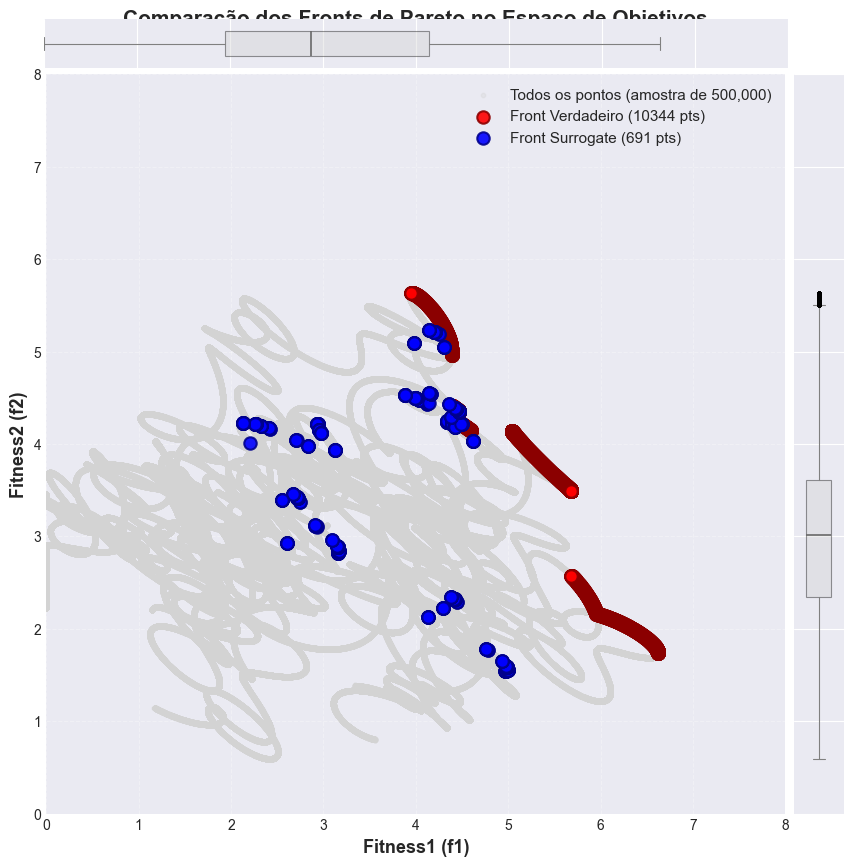

⚠️  AVISO: Esta função está deprecated. Use display_fitness_landscape_with_paretos() para múltiplos fronts.


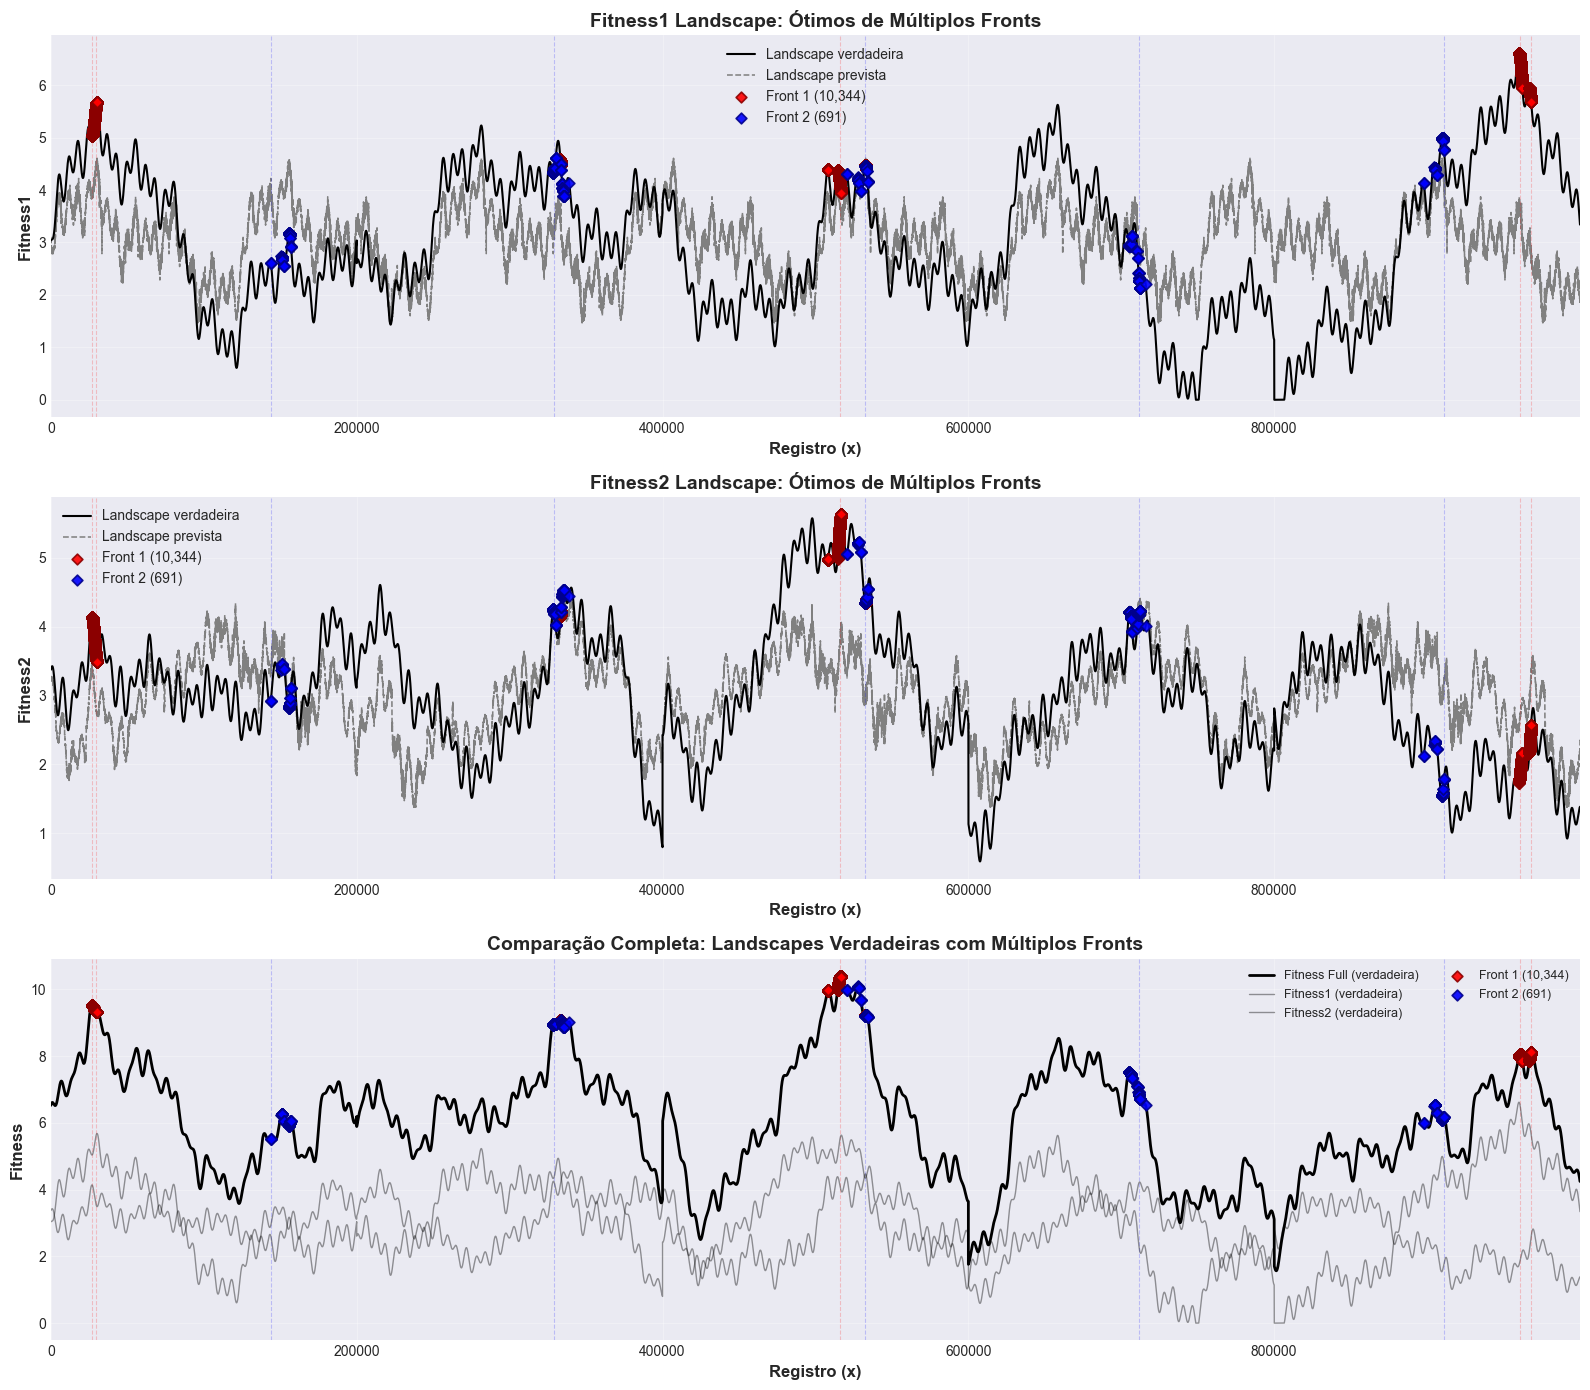

In [4]:
gamma_results = calculate_gamma_convergence_metric(df1, df_pareto_real1, df_pareto_surrogate1)
print_gamma_metric(gamma_results)
display_two_pareto_fronts(df1, df_pareto_real1, df_pareto_surrogate1)
display_fitness_landscape_with_2pareto(df1, df_pareto_real1, df_pareto_surrogate1)

#### Problema 2

In [5]:
df_pareto_real2 = find_pareto_front(df2)

df_predicted = df2.copy().drop(columns=['fitness1', 'fitness2'])
df_predicted.rename(columns={'fitness1_c1': 'fitness1', 'fitness2_c1': 'fitness2'}, inplace=True)
df_pareto_surrogate2 = find_pareto_front(df_predicted)

df_pareto_real2 = df2[df2.registro.isin(df_pareto_real2.registro.unique())]
df_pareto_surrogate2 = df2[df2.registro.isin(df_pareto_surrogate2.registro.unique())]

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 4,416 pontos.
Isso representa 0.4416% do espaço de busca.
Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 691 pontos.
Isso representa 0.0691% do espaço de busca.


🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        2.259242
   • Desvio Padrão:            1.710959


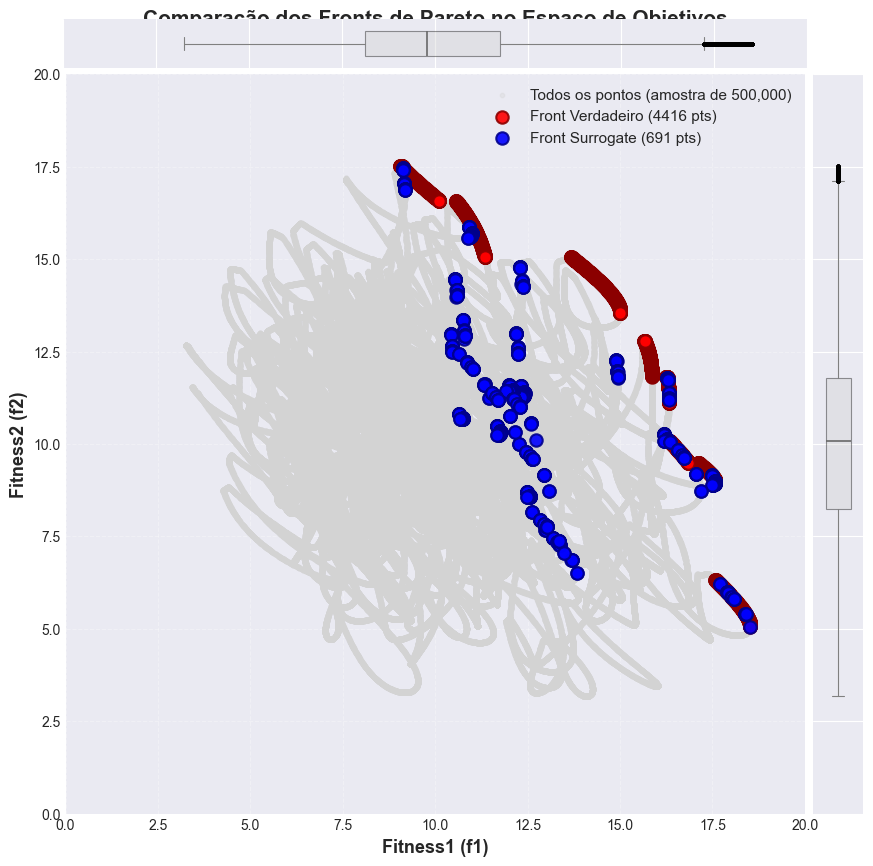

⚠️  AVISO: Esta função está deprecated. Use display_fitness_landscape_with_paretos() para múltiplos fronts.


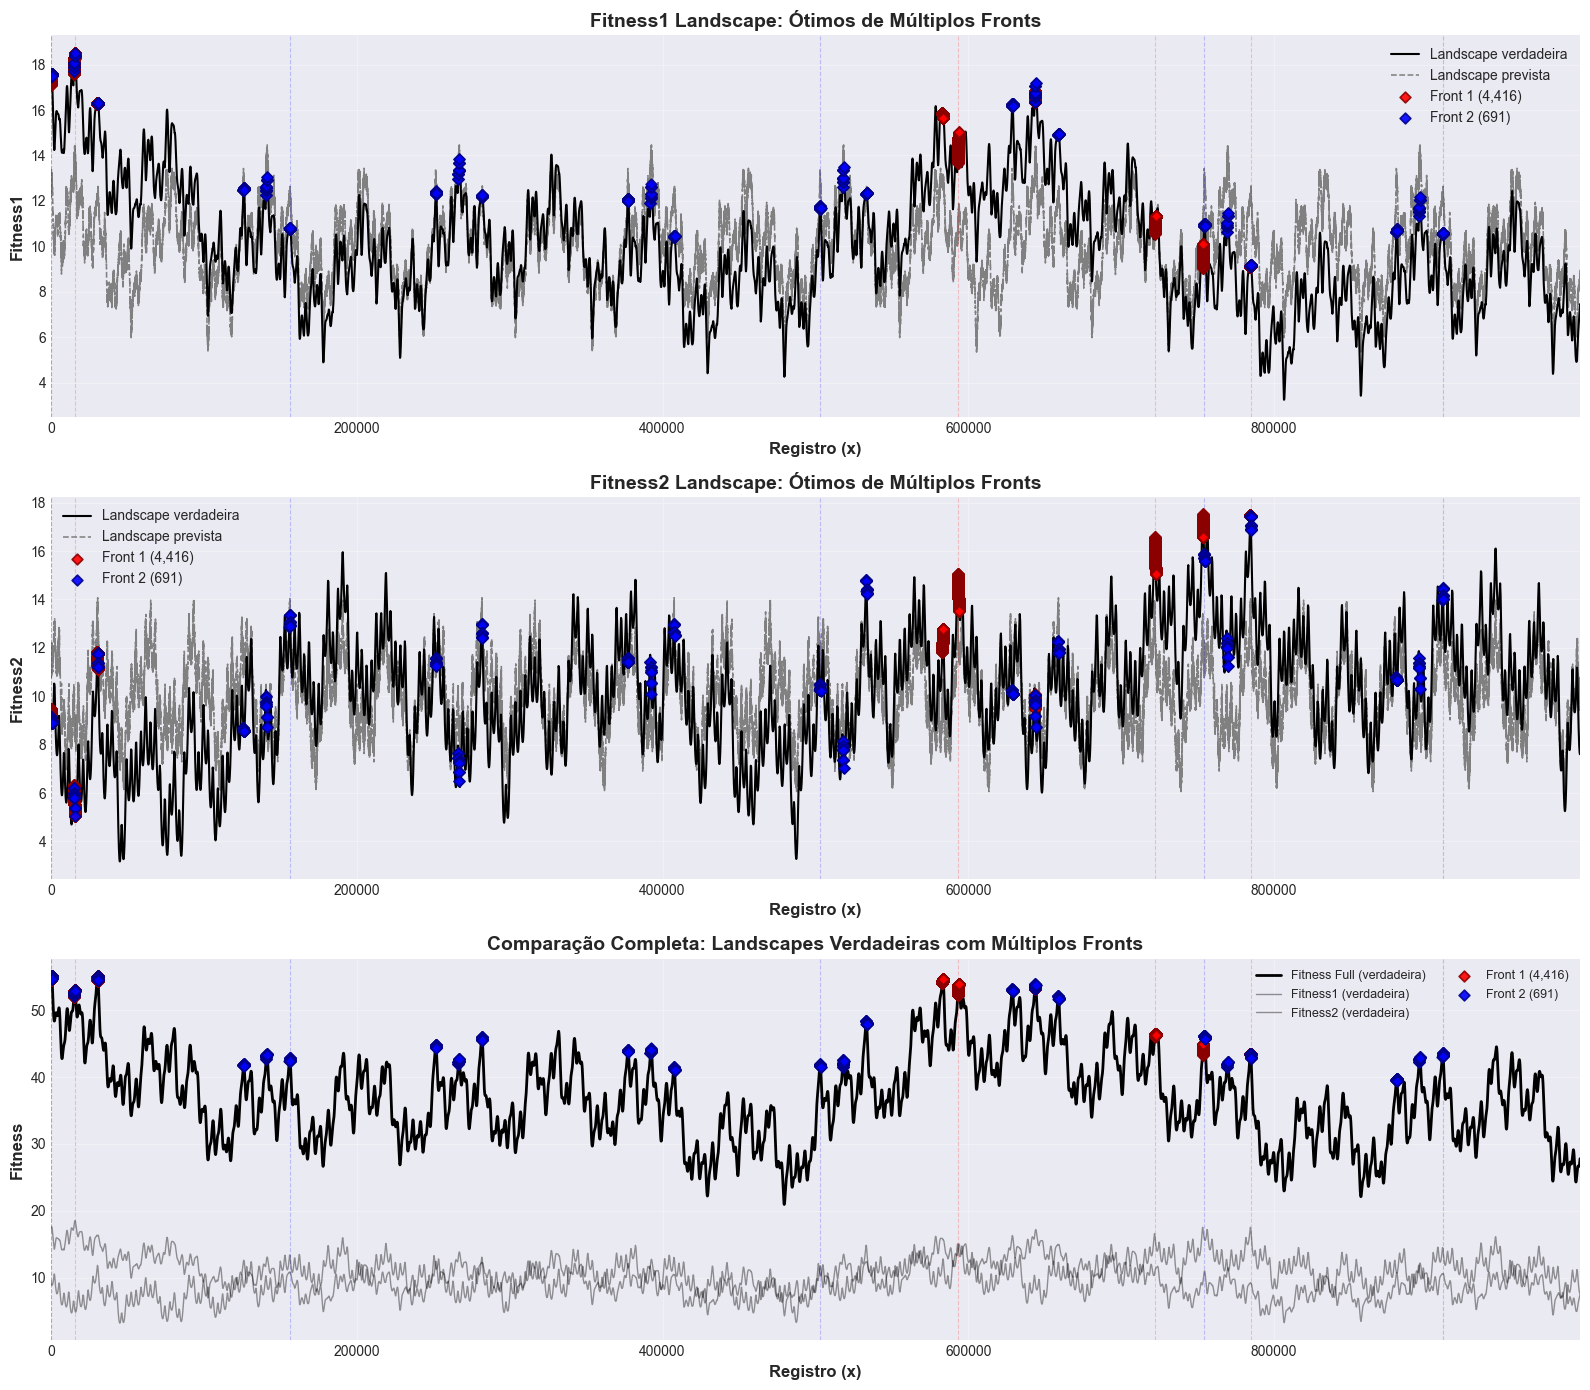

In [6]:
gamma_results = calculate_gamma_convergence_metric(df2, df_pareto_real2, df_pareto_surrogate2)
print_gamma_metric(gamma_results)
display_two_pareto_fronts(df2, df_pareto_real2, df_pareto_surrogate2)
display_fitness_landscape_with_2pareto(df2, df_pareto_real2, df_pareto_surrogate2)

# 2. NSGA-II

Vamos implementar o algoritmo NSGA-II de duas formas:
1. Usando a biblioteca pymoo (implementação otimizada)
2. Implementação própria seguindo o algoritmo original

Configuração dos Experimentos
* Cada indivíduo será representado como uma lista de 6 dígitos [d1, d2, d3, d4, d5, d6], onde cada elemento pode variar de 0 a 9
* Formando um número de 0 a 999999 que representa um registro do dataframe (df_landscape).

### 2.1. Pymoo

In [7]:
import numpy as np
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.optimize import minimize
import copy


####################################################################################################
####################################################################################################

### Mapeamento genótipo <> fenótipo
def genotype_to_registro(genotype):
    """Converte lista de 6 dígitos em número de registro"""
    return int(''.join(map(str, genotype)))

def registro_to_genotype(registro):
    """Converte número de registro em lista de 6 dígitos"""
    return [int(d) for d in f"{registro:06d}"]


# Definição do problema para pymoo
class DigitOptimizationProblem(Problem):
    
    ##############################################
    ############### Inicializa problema / genótipo
    def __init__(self, df_landscape, config):
        """
        Problema de otimização bi-objetivo onde cada indivíduo é representado
        por 6 dígitos (0-9) que formam um registro do dataframe
        """
        ### definindo o problema
        self.df_landscape = df_landscape
        self.fitness_cols = config['fitness_cols']
        self.maximize = config['maximize']

        ### definindo o genótipo        
        super().__init__(
            n_var    = config['tamanho_genotipo'],      # 6 variáveis (dígitos)
            n_obj    = config['n_objetivos'],           # 2 objetivos
            n_constr = config['n_restricoes'],          # Sem restrições
            xl       = config['limite_inferior'],       # Limite inferior
            xu       = config['limite_superior'],       # Limite superior
            type_var = config['tipo_variavel_genotipo'] # Variáveis inteiras
        )
    
    ##############################################
    ########################### Fitness evaluation

    ### Avalia Fitness 1 indivíduo
    def individual_fitness_evaluation(self, genotype, df_landscape, fitness_cols, maximize = False):
        """Obtém fitness do dataframe para um determinado genótipo"""

        # Identifica a solucao no dataframe de fitness landscape
        registro = genotype_to_registro(genotype)
        row = df_landscape[df_landscape['registro'] == registro]

        # Coleta fitness (se registro não existe, retornar valores muito ruins)
        if len(row) == 0:
            fitness1 = 1e6
            fitness2 = 1e6
        else:
            fitness1 = row[fitness_cols[0]].values[0]
            fitness2 = row[fitness_cols[1]].values[0]

        # Se for um problema de maximizacao, inverte os valores de fitness
        if maximize:
            fitness1 = -fitness1
            fitness2 = -fitness2
        
        return [fitness1, fitness2]


    ### Avalia Fitness 1 população
    def _evaluate(self, X, out, *args, **kwargs):
        """
        Avalia a população X e retorna os objetivos
        """
        n_individuals = X.shape[0]
        objectives = np.zeros((n_individuals, 2))
        
        for i in range(n_individuals):
            genotype = X[i].tolist()
            objectives[i] = self.individual_fitness_evaluation(genotype, self.df_landscape, self.fitness_cols, self.maximize)
        
        out["F"] = objectives



####################################################################################################
####################################################################################################
def run_nsga2_pymoo(config, 
                    df_landscape,
                    return_initial_pop=False,
                    ):
    '''
    Funcao para executar o NSGA-II com a biblioteca pymoo
    '''

    ##############################################
    ############################# Execucao NSGA-II

    # Define o problema
    problem = DigitOptimizationProblem(df_landscape, config)

    # Configura o algoritmo
    algorithm = NSGA2(
        pop_size=config['population_size'],
        sampling=IntegerRandomSampling(),
        crossover=SBX(prob=config['crossover_prob'], eta=config['crossover_eta'], vtype=int),
        mutation=PM(prob=config['mutation_prob'], eta=config['mutation_eta'], vtype=int),
        eliminate_duplicates=True
    )

    # Executa otimização (pymoo sempre minimiza)
    resultado_otimizacao = minimize(
        problem,
        algorithm,
        ('n_gen', config['n_generations']),
        seed=config['seed'],
        save_history=return_initial_pop,  # Salvar histórico para capturar população inicial
        verbose = False #True
    )


    ##############################################
    ################################### Resultados

    # Extrai soluções do front de Pareto
    pareto_genotypes = resultado_otimizacao.X
    pareto_objectives = resultado_otimizacao.F

    # Converte para registros e cria dataframe
    registros = [genotype_to_registro(g) for g in pareto_genotypes]
    df_pareto = df_landscape[df_landscape['registro'].isin(registros)].copy()

    # Capturar população inicial
    if return_initial_pop:
        initial_population = resultado_otimizacao.history[0].pop.get("X")
    else:
        initial_population = None

    print(f"\n✅ Otimização concluída!")
    print(f"Soluções encontradas no front: {len(pareto_genotypes)}")
    print(f"Registros únicos no dataframe: {len(df_pareto)}")


    return df_pareto, resultado_otimizacao, resultado_otimizacao

### 2.2. my NSGA-II
Implementação Própria do algoritmo NSGA-II seguindo o paper original de Deb et al. (2002)

In [8]:
from src.nsgaII import run_my_nsga2

/Users/gmello/Documents/python_venvs/mestrado_estatistica/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 3. Experimentos

In [9]:
# Parâmetros NSGA-II
config = {
    # definindo o algoritmo
    'population_size': 100,
    'n_generations': 50, #200,
    'k_tournament': 2,
    'crossover_prob': 0.9,
    'crossover_eta': 15,
    'mutation_prob': 1/6,  # 1/n_var
    'mutation_eta': 20,
    'seed': 42,
    'track_progress': True,

    # definindo o problema
    'n_objetivos': 2,
    'fitness_cols': ["fitness1", "fitness2"],
    'maximize': True,
    'n_restricoes': 0,

    # definindo o genótipo
    'tamanho_genotipo': 6,
    'limite_inferior': np.array([0, 0, 0, 0, 0, 0]),
    'limite_superior': np.array([9, 9, 9, 9, 9, 9]),
    'tipo_variavel_genotipo': int
}

### Problema 1. Landscape Real

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 10,344 pontos.
Isso representa 1.0344% do espaço de busca.

✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 100


100%|██████████| 50/50 [00:03<00:00, 14.44it/s]



✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 90


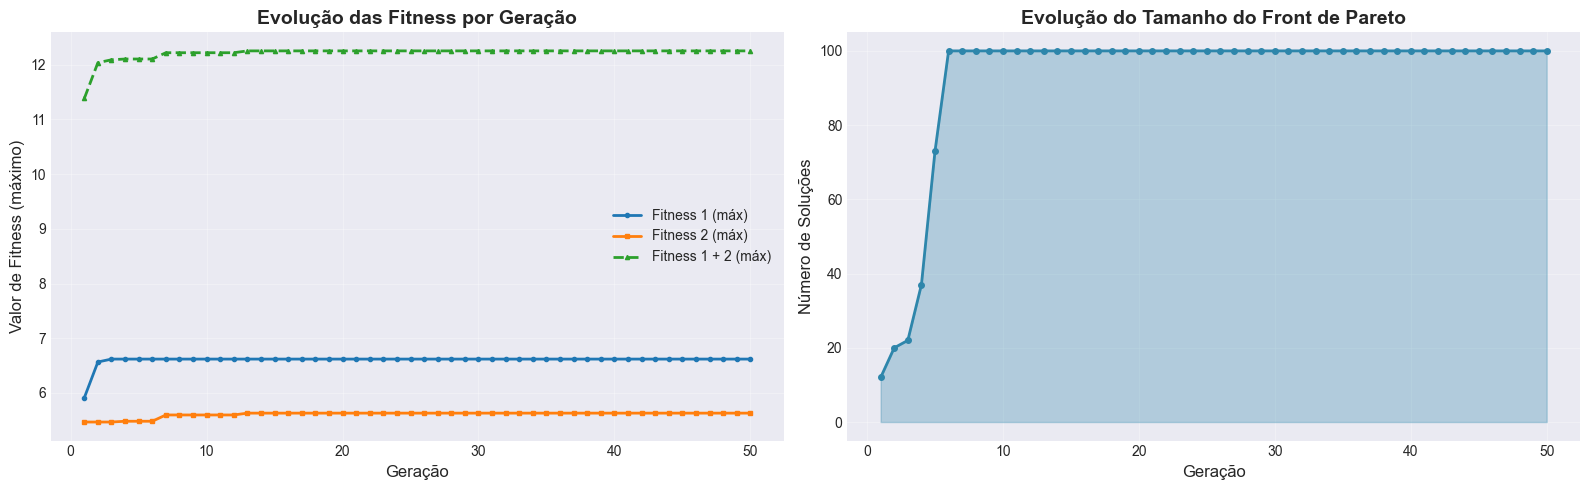


✅ Gráficos de progresso gerados com sucesso!


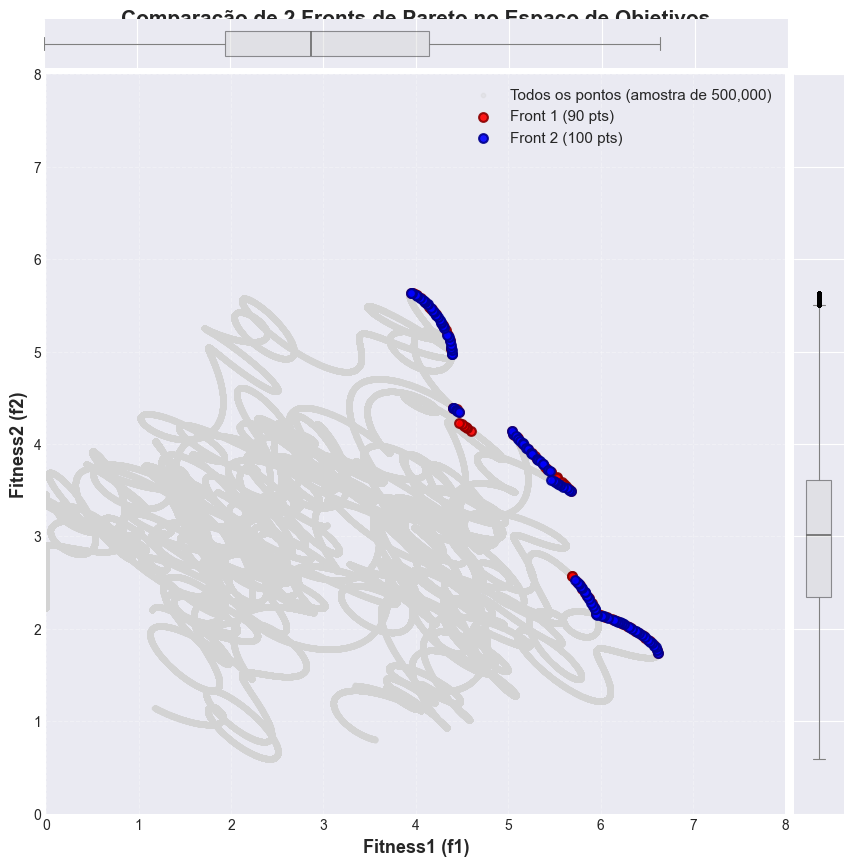

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.014404
   • Desvio Padrão:            0.013698


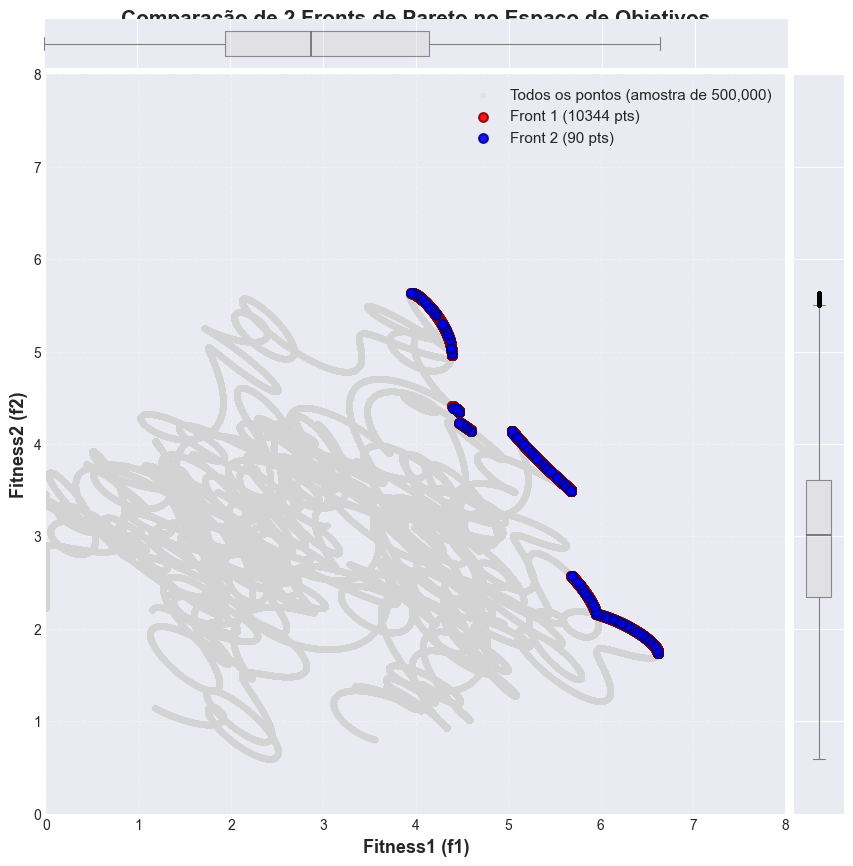

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.000296
   • Desvio Padrão:            0.001375


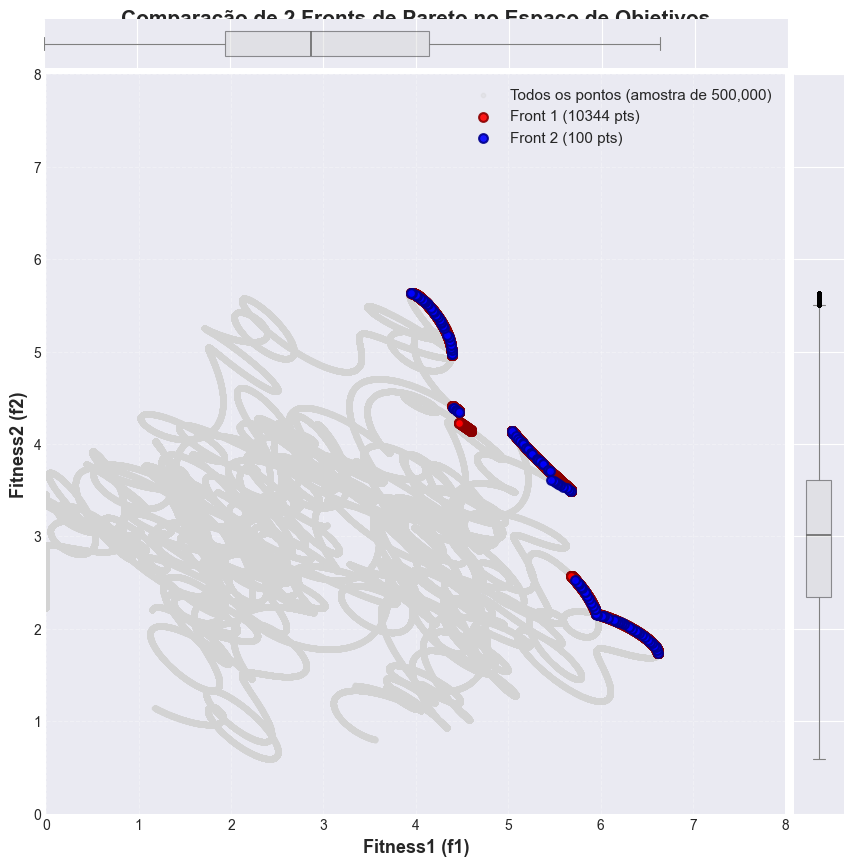

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.003755
   • Desvio Padrão:            0.011255


In [10]:
# experimento
df = df1.copy()
df_pareto_real      = find_pareto_front(df)
df_pareto_moo, _, _ = run_nsga2_pymoo(config, df)
df_pareto_my, _, _, history = run_my_nsga2(config, df, save_history=True)

# convergencia entre resultados
#display_pareto_fronts3(df, [df_pareto_real, df_pareto_my, df_pareto_moo])
display_pareto_fronts3(df, [df_pareto_my, df_pareto_moo])
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_my, df_pareto_moo)
print_gamma_metric(gamma_results)

# resultados my nsga2
display_pareto_fronts3(df, [df_pareto_real, df_pareto_my])
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_my)
print_gamma_metric(gamma_results)

# resultados pymoo
display_pareto_fronts3(df, [df_pareto_real, df_pareto_moo])
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_moo)
print_gamma_metric(gamma_results)

#### Visualizar evolução das populações

In [11]:
# Gerar GIF com a evolução das populações
caminho_gif = gerar_gif_evolucao_nsga2(
    df_landscape=df1,  # Mesmo dataframe usado acima
    history=history,
    nome_arquivo='evolucao_nsga2_df1.gif',
    fps=5,  # Ajuste a velocidade conforme preferir
    output_dir='data'
)

print(f"GIF salvo em: {caminho_gif}")

Iniciando a geração de 51 frames...
Processado 10/51 frames...
Processado 20/51 frames...
Processado 30/51 frames...
Processado 40/51 frames...
Processado 50/51 frames...
Salvando arquivo 'evolucao_nsga2_df1.gif' no diretório 'data'...

✅ Sucesso! GIF gerado em:
/Users/gmello/Documents/python_repos/mestrado/ua-dd-saea/data/evolucao_nsga2_df1.gif
GIF salvo em: /Users/gmello/Documents/python_repos/mestrado/ua-dd-saea/data/evolucao_nsga2_df1.gif


In [12]:
df_history = history_to_dataframe(history).drop(columns=['id_solucao'])
df_history = df_history.sort_values(by=['geracao','genotipo'])
df_history['id_solucao'] = df_history.groupby(['geracao']).cumcount() + 1
df_history.head()

,geracao,genotipo,id_solucao
83,0,2985,1
78,0,15948,2
25,0,39998,3
91,0,62463,4
51,0,63522,5


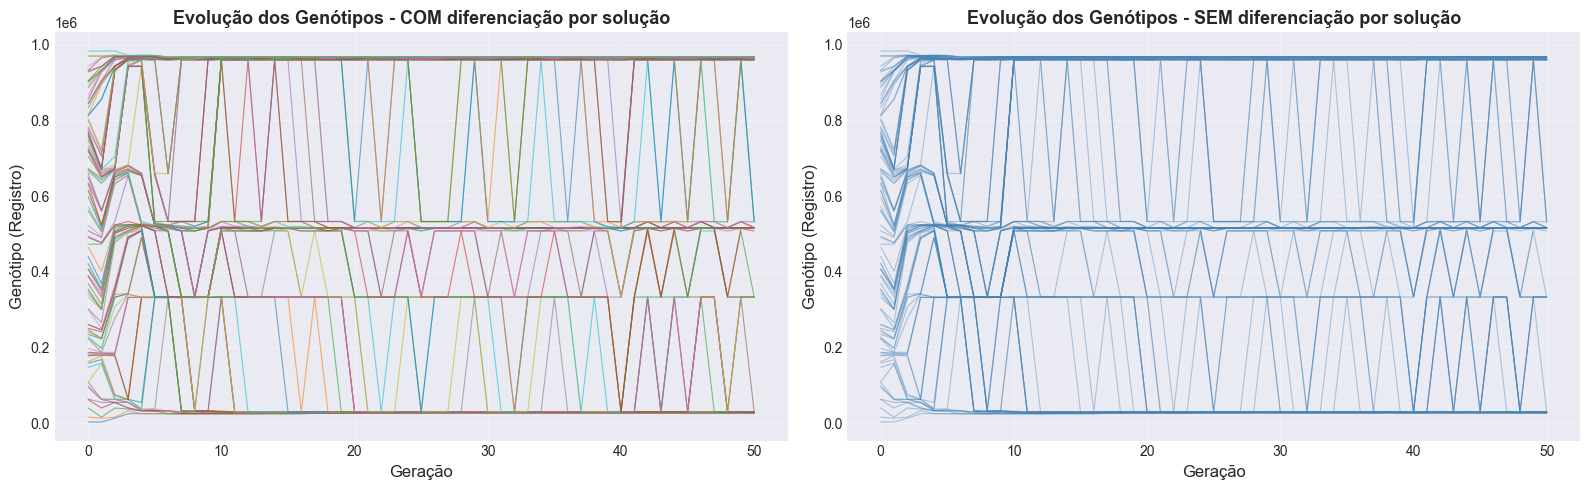


📊 Estatísticas do histórico:
   • Total de registros: 5,100
   • Gerações: 51
   • Soluções por geração: 100
   • Genótipos únicos visitados: 985


In [13]:
display_evolution_of_genotypes(df_history)

### Problema 1. Landscape Previsto

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 691 pontos.
Isso representa 0.0691% do espaço de busca.


100%|██████████| 50/50 [00:03<00:00, 13.34it/s]



✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 51


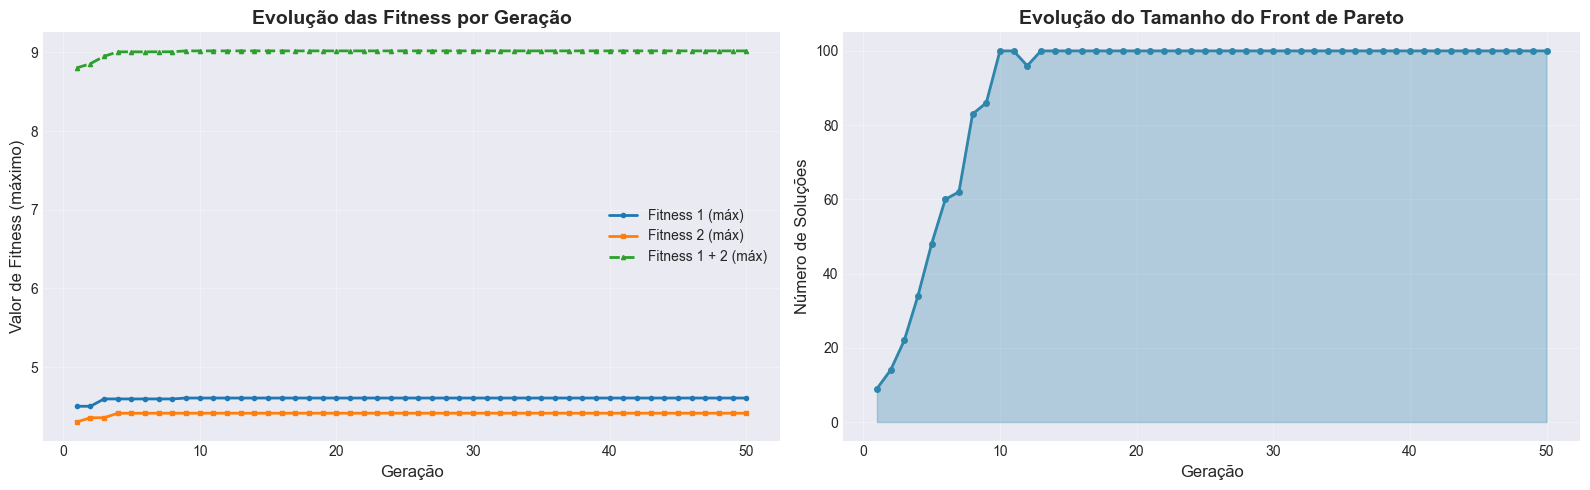


✅ Gráficos de progresso gerados com sucesso!

✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 100


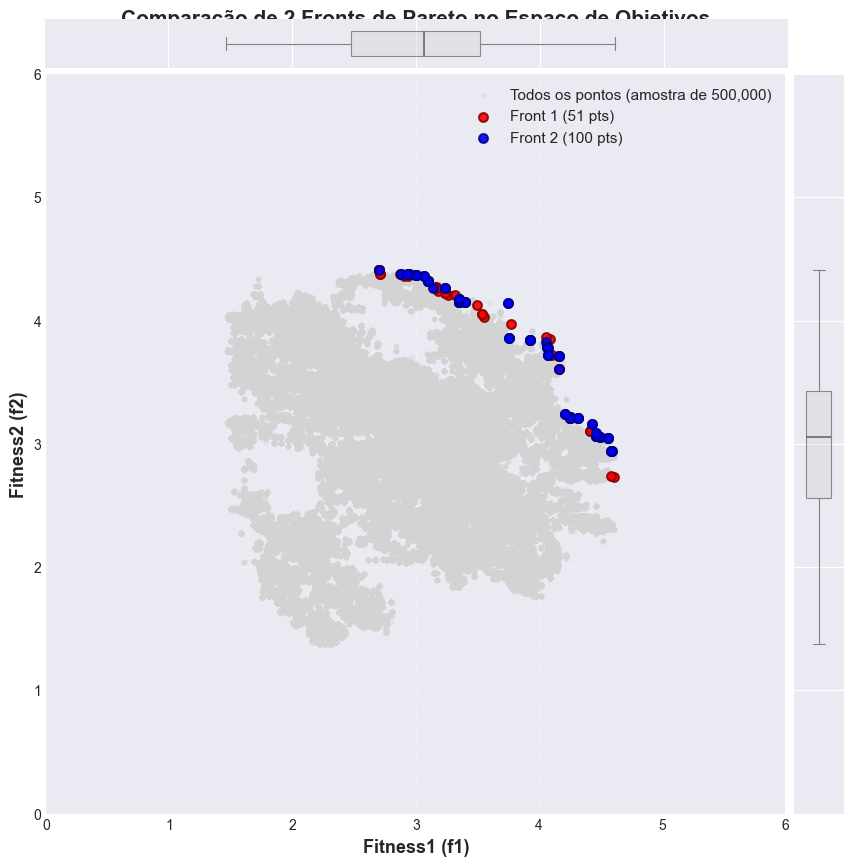

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.037353
   • Desvio Padrão:            0.044684


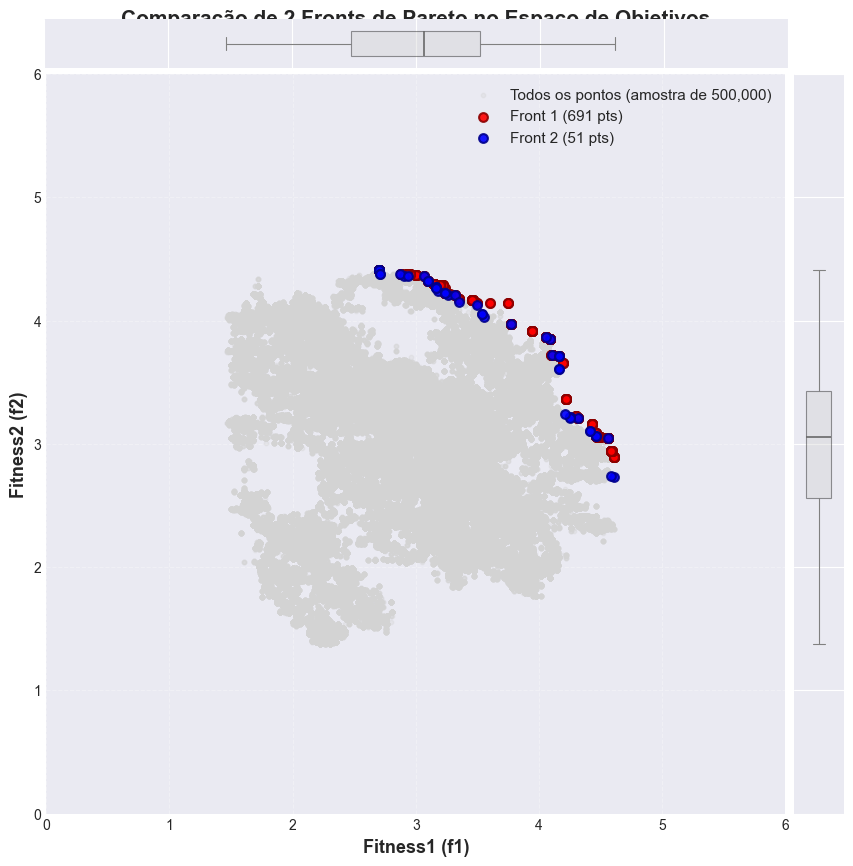

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.028810
   • Desvio Padrão:            0.039578


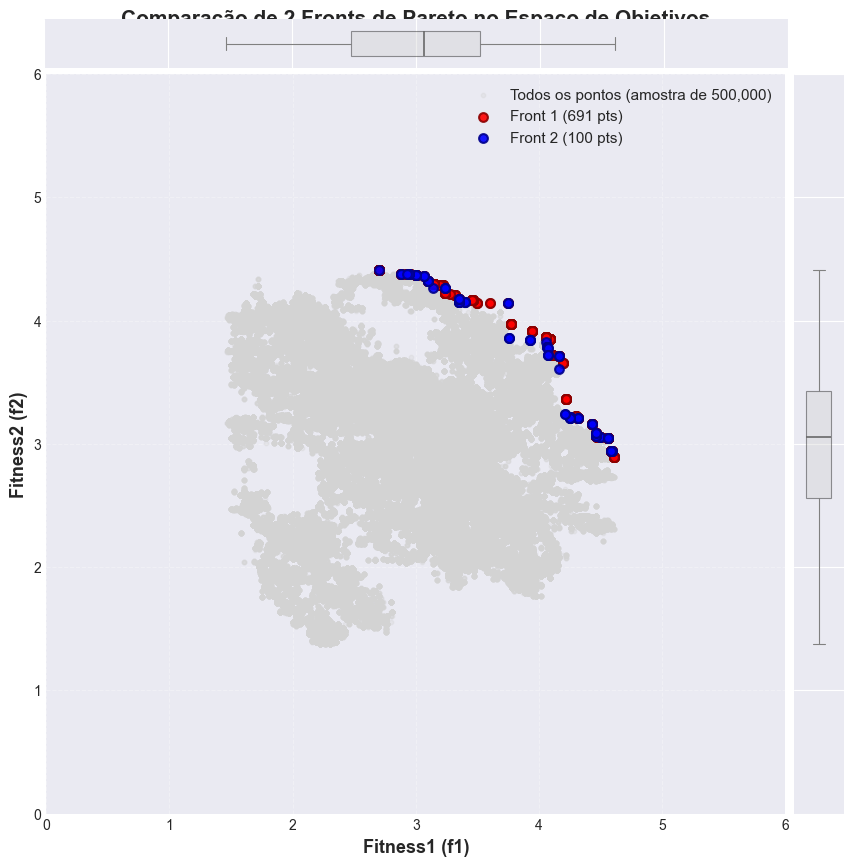

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.025168
   • Desvio Padrão:            0.032045


In [14]:
# experimento
df_predicted = df1.copy().drop(columns=['fitness1', 'fitness2'])
df_predicted.rename(columns={'fitness1_c1': 'fitness1', 'fitness2_c1': 'fitness2'}, inplace=True)

df_pareto_surrogate = find_pareto_front(df_predicted)
df_pareto_my, _, _, _  = run_my_nsga2(config, df_predicted)
df_pareto_moo, _, _ = run_nsga2_pymoo(config, df_predicted)

# convergencia entre resultados
#display_pareto_fronts3(df_predicted, [df_pareto_real, df_pareto_my, df_pareto_moo])
display_pareto_fronts3(df_predicted, [df_pareto_my, df_pareto_moo])
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_my, df_pareto_moo)
print_gamma_metric(gamma_results)

# resultados my nsga2
display_pareto_fronts3(df_predicted, [df_pareto_surrogate, df_pareto_my])
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_surrogate, df_pareto_my)
print_gamma_metric(gamma_results)

# resultados pymoo
display_pareto_fronts3(df_predicted, [df_pareto_surrogate, df_pareto_moo])
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_surrogate, df_pareto_moo)
print_gamma_metric(gamma_results)


### Problema 2. Landscape Real

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 4,416 pontos.
Isso representa 0.4416% do espaço de busca.


100%|██████████| 50/50 [00:03<00:00, 14.49it/s]



✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 86


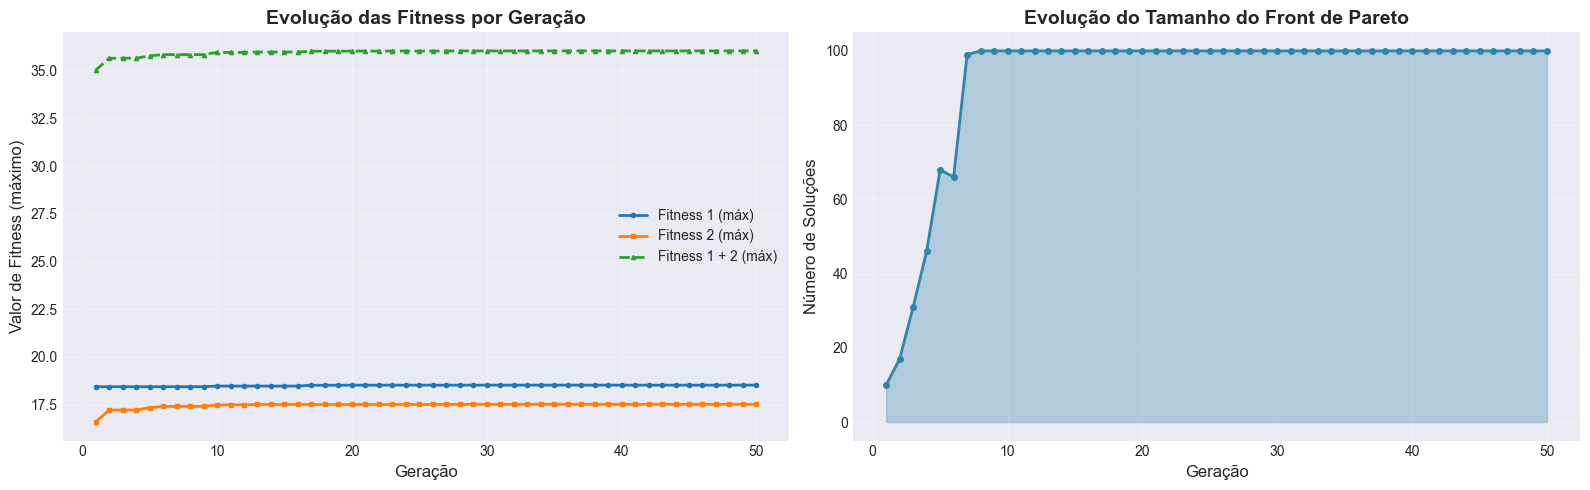


✅ Gráficos de progresso gerados com sucesso!

✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 100


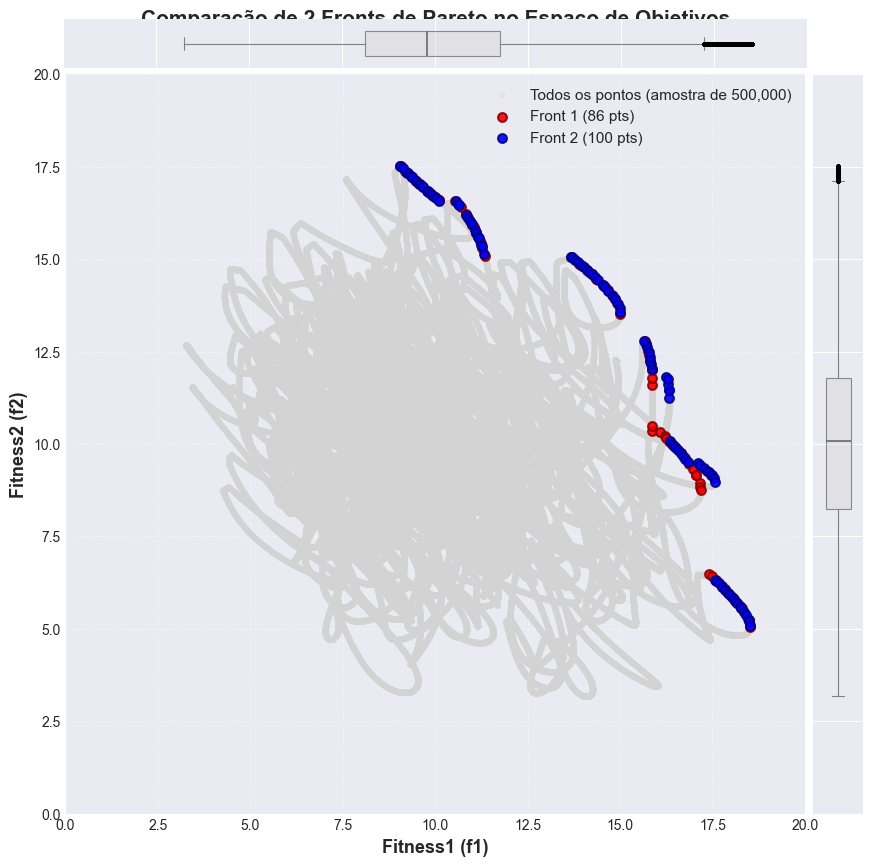

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.089206
   • Desvio Padrão:            0.131502


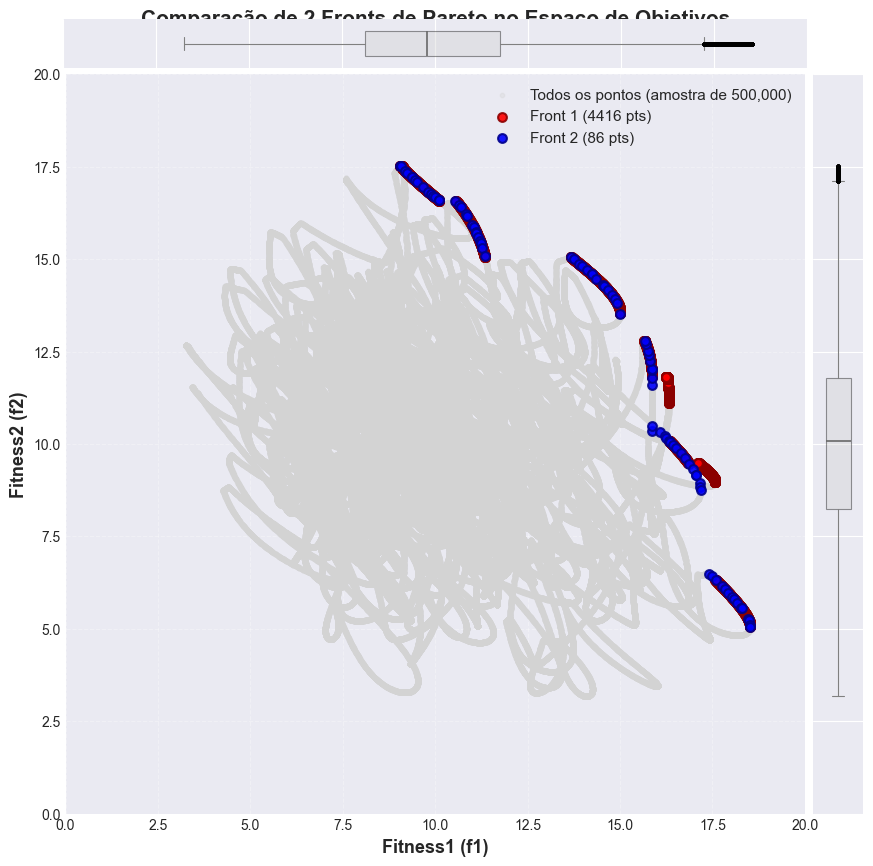

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.052742
   • Desvio Padrão:            0.129848


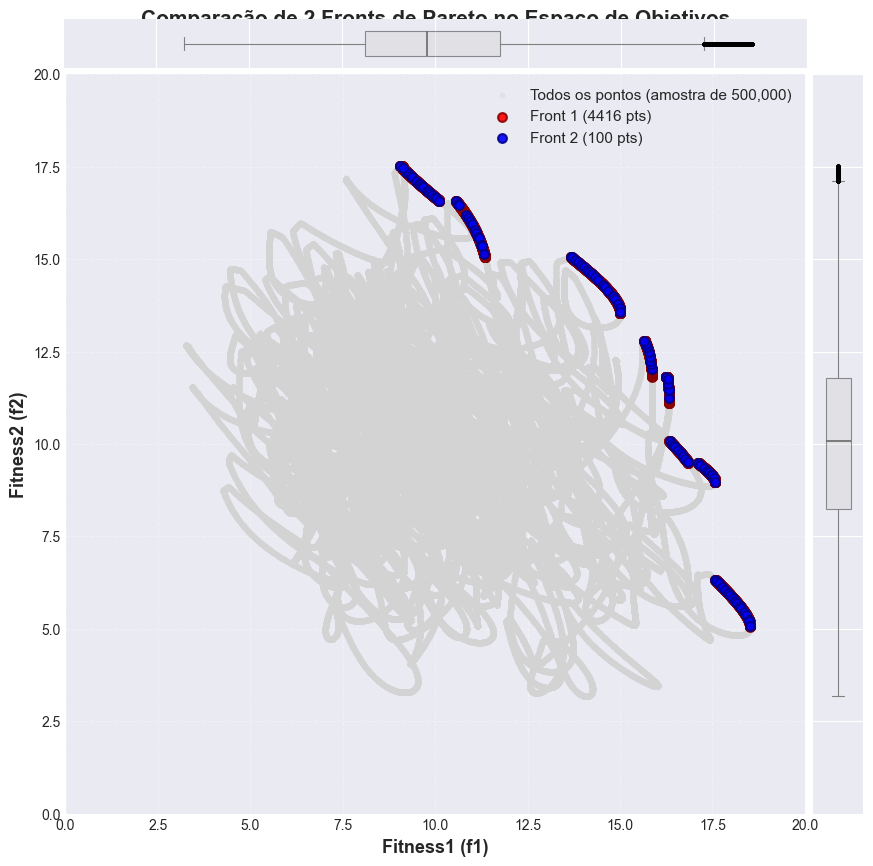

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.000133
   • Desvio Padrão:            0.000837


In [15]:
# experimento
df = df2.copy()
df_pareto_real      = find_pareto_front(df)
df_pareto_my, _, _, _  = run_my_nsga2(config, df)
df_pareto_moo, _, _ = run_nsga2_pymoo(config, df)

# convergencia entre resultados
#display_pareto_fronts3(df, [df_pareto_real, df_pareto_my, df_pareto_moo])
display_pareto_fronts3(df, [df_pareto_my, df_pareto_moo])
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_my, df_pareto_moo)
print_gamma_metric(gamma_results)

# resultados my nsga2
display_pareto_fronts3(df, [df_pareto_real, df_pareto_my])
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_my)
print_gamma_metric(gamma_results)

# resultados pymoo
display_pareto_fronts3(df, [df_pareto_real, df_pareto_moo])
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_moo)
print_gamma_metric(gamma_results)

### Problema 2. Landscape Previsto

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 691 pontos.
Isso representa 0.0691% do espaço de busca.


100%|██████████| 50/50 [00:04<00:00, 11.27it/s]



✅ Otimização concluída!
Soluções encontradas no front: 100
Registros únicos no dataframe: 25


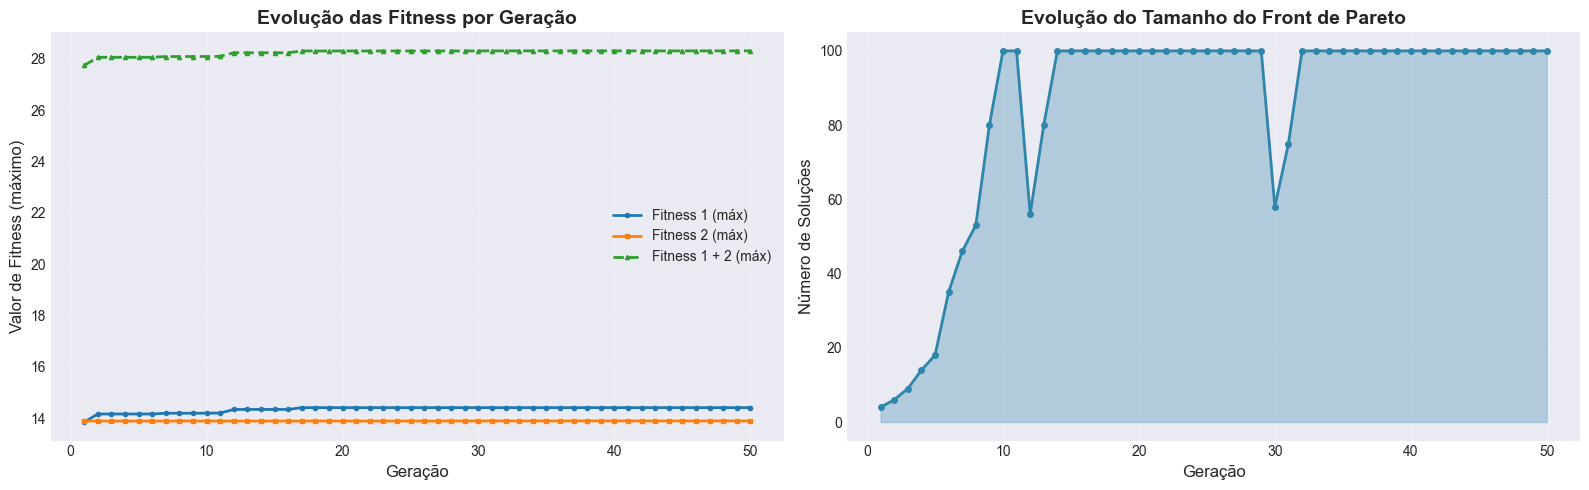


✅ Gráficos de progresso gerados com sucesso!

✅ Otimização concluída!
Soluções encontradas no front: 69
Registros únicos no dataframe: 69


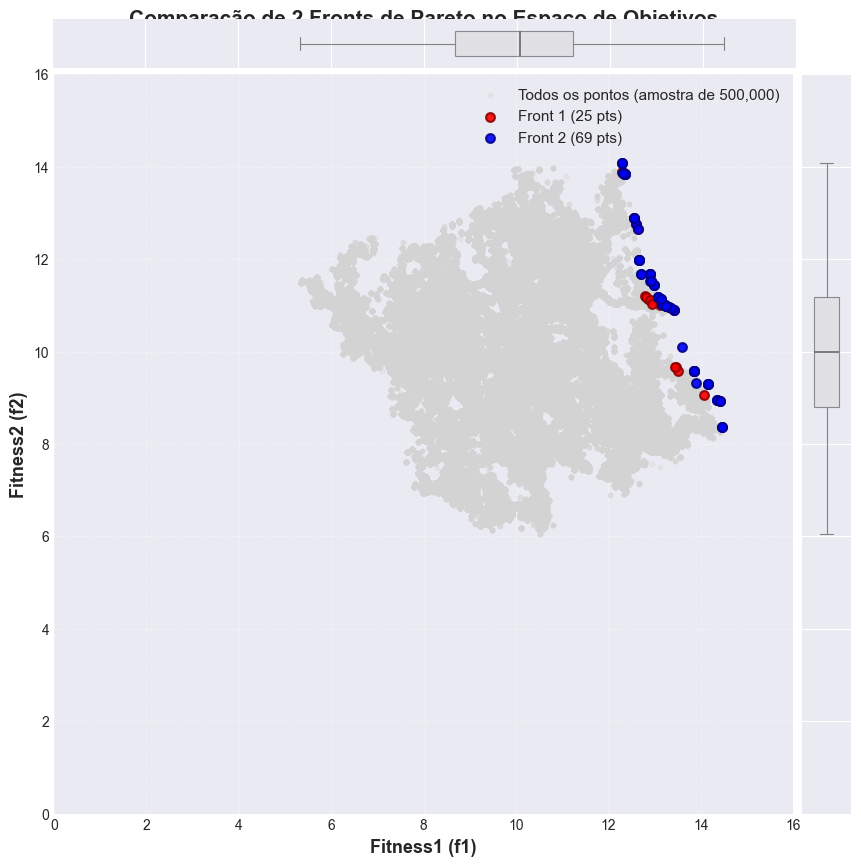

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.198769
   • Desvio Padrão:            0.222736


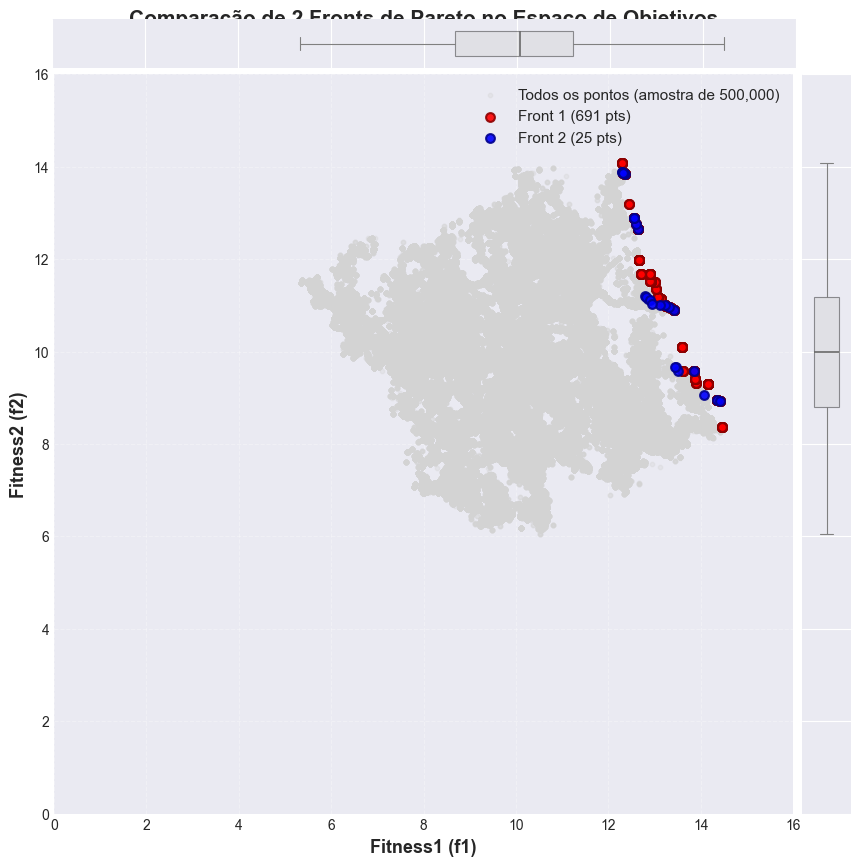

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.082277
   • Desvio Padrão:            0.101563


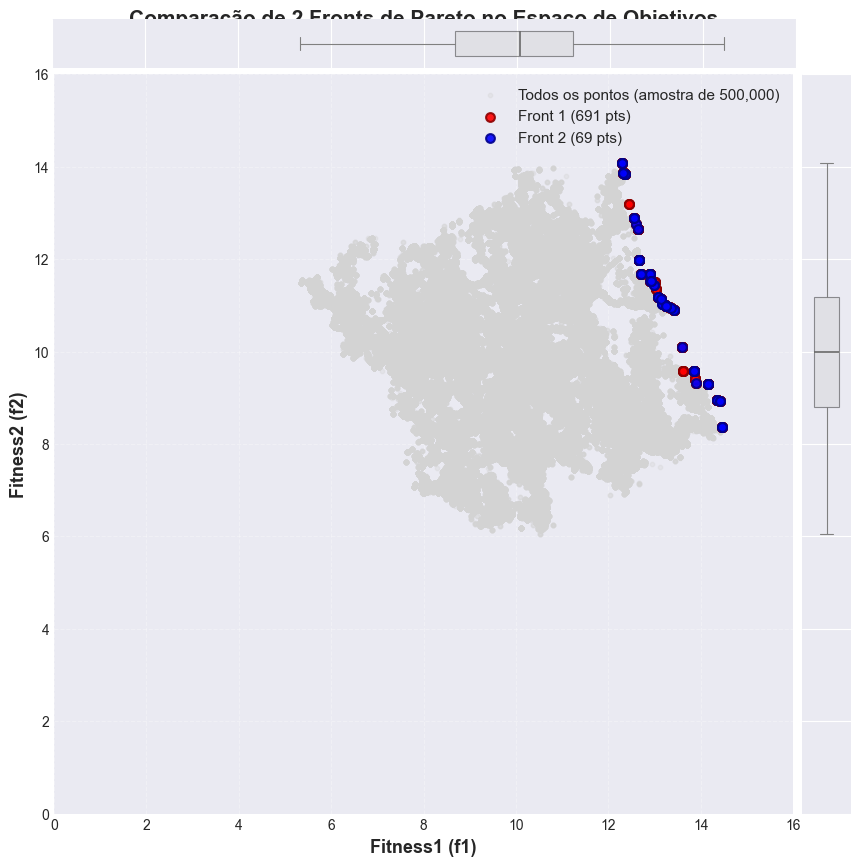

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.004140
   • Desvio Padrão:            0.013164


In [16]:
# experimento
df_predicted = df2.copy().drop(columns=['fitness1', 'fitness2'])
df_predicted.rename(columns={'fitness1_c1': 'fitness1', 'fitness2_c1': 'fitness2'}, inplace=True)

df_pareto_surrogate = find_pareto_front(df_predicted)
df_pareto_my, _, _, _  = run_my_nsga2(config, df_predicted)
df_pareto_moo, _, _ = run_nsga2_pymoo(config, df_predicted)

# convergencia entre resultados
#display_pareto_fronts3(df_predicted, [df_pareto_real, df_pareto_my, df_pareto_moo])
display_pareto_fronts3(df_predicted, [df_pareto_my, df_pareto_moo])
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_my, df_pareto_moo)
print_gamma_metric(gamma_results)

# resultados my nsga2
display_pareto_fronts3(df_predicted, [df_pareto_surrogate, df_pareto_my])
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_surrogate, df_pareto_my)
print_gamma_metric(gamma_results)

# resultados pymoo
display_pareto_fronts3(df_predicted, [df_pareto_surrogate, df_pareto_moo])
gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_surrogate, df_pareto_moo)
print_gamma_metric(gamma_results)


# Outros

### Comparando funções de crossover e mutação com Pymoo 
* (não são similares)